In [1]:
import pandas as pd
import os
from google.colab import drive

# 1. Adım: Google Drive'ı Colab'a Bağla
drive.mount('/content/drive')

# 2. Adım: Drive'daki Klasör Yolunu Tanımla
klasor_yolu = '/content/drive/MyDrive/TOTTİK/Veri Analizi/veri/'

veri_cerceveleri = []

# ========================================================
# KISIM 1: Eski Ülkeler (Excel Formatı - Tek Dosya)
# ========================================================
eski_dosyalar = {
    'ABD': os.path.join(klasor_yolu, 'abd.xlsx'),
    'Almanya': os.path.join(klasor_yolu, 'almanya.xlsx'),
    'Brezilya': os.path.join(klasor_yolu, 'brezilya.xlsx'),
    'Güney Kore': os.path.join(klasor_yolu, 'güneykore.xlsx')
}

sutun_eslesmeleri = {
    'ABD': {'observation_date': 'Tarih', 'SURETIM': 'SURETIM', 'TUFE': 'TUFE', 'ISSIZLIK': 'ISSIZLIK', 'ISFAIZ': 'ISFAIZ'},
    'Almanya': {'observation_date': 'Tarih', 'Almanya_SURETIM': 'SURETIM', 'Almanya_TUFE': 'TUFE', 'Almanya_ISSIZLIK': 'ISSIZLIK', 'Almanya_ISFAIZ': 'ISFAIZ'},
    'Brezilya': {'observation_date': 'Tarih', 'Brezilya_SURETIM': 'SURETIM', 'Brezilya_TUFE': 'TUFE', 'Brezilya_ISSIZLIK': 'ISSIZLIK', 'Brezilya_ISFAIZ': 'ISFAIZ'},
    'Güney Kore': {'observation_date': 'Tarih', 'GüneyKore_SURETIM': 'SURETIM', 'GüneyKore_TUFE': 'TUFE', 'GüneyKoore_ISSIZLIK': 'ISSIZLIK', 'GüneyKore_ISFAIZ': 'ISFAIZ'}
}

print("1. Adım: Eski ülkelerin verileri (Excel) yükleniyor...")
print("-" * 60)

for ulke, dosya_adi in eski_dosyalar.items():
    if os.path.exists(dosya_adi):
        try:
            df = pd.read_excel(dosya_adi)

            # Sadece mevcut olan sütunları filtrele (Hata almamak için)
            gerekli_sutunlar = [col for col in sutun_eslesmeleri[ulke].keys() if col in df.columns]
            df = df[gerekli_sutunlar].copy()

            # Sütun adlarını standartlaştır
            df.rename(columns=sutun_eslesmeleri[ulke], inplace=True)
            df['Tarih'] = pd.to_datetime(df['Tarih'])
            df.insert(0, 'Ülke', ulke)

            veri_cerceveleri.append(df)
            print(f"✅ {ulke} Excel verisi başarıyla havüza eklendi.")
        except Exception as e:
            print(f"❌ Hata! {ulke} Excel verisi okunurken sorun oluştu: {e}")
    else:
        print(f"⚠️ Uyarı: {ulke} için Excel dosyası klasörde bulunamadı, atlanıyor... ({dosya_adi})")


# ========================================================
# KISIM 2: Yeni Ülkeler (CSV Formatı - Parçalı Dosyalar)
# ========================================================
yeni_dosyalar = {
    'Türkiye': {
        'TUFE': 'türkiye_tufe.csv',
        'SURETIM': 'türkiye_sanayitüketimi.csv',
        'ISSIZLIK': 'türkiye_işsizlik.csv',
        'ISFAIZ': 'türkiye_faizoranı.csv'
    },
    'Polonya': {
        'TUFE': 'polonya_tüfe.csv',
        'SURETIM': 'polonya_sanayiüretimi.csv',
        'ISSIZLIK': 'polonya_işsizlik.csv',
        'ISFAIZ': 'polonya_faizoranı.csv'
    },
    'Meksika': {
        'TUFE': 'meksika_tüfe.csv',
        'SURETIM': 'meksika_sanayiüretimi.csv',
        'ISSIZLIK': 'meksika_işsizlik.csv',  # Dosya yoksa bile sistem donmaz, pas geçer
        'ISFAIZ': 'meksika_faizoranı.csv'    # Dosya yoksa bile sistem donmaz, pas geçer
    },
    'Japonya': {
        'TUFE': 'japan_tufe.csv',
        'SURETIM': 'japan_sanayiüretimi.csv',
        'ISSIZLIK': 'japan_işsizlik.csv',  # Dosya yoksa bile sistem donmaz, pas geçer
        'ISFAIZ': 'japonya_faizoranı.csv'    # Dosya yoksa bile sistem donmaz, pas geçer
    }
}

print("\n2. Adım: Yeni ülkelerin verileri (CSV) birleştiriliyor...")
print("-" * 60)

for ulke, dosyalar in yeni_dosyalar.items():
    ulke_df = None

    for degisken, dosya_adi in dosyalar.items():
        tam_yol = os.path.join(klasor_yolu, dosya_adi)

        if os.path.exists(tam_yol):
            try:
                gecici_df = pd.read_csv(tam_yol)

                # Dinamik sütun yakalama: 1. sütun Tarih, 2. sütun değer
                mevcut_tarih_sutunu = gecici_df.columns[0]
                deger_sutunu = gecici_df.columns[1]

                gecici_df = gecici_df.rename(columns={mevcut_tarih_sutunu: 'Tarih', deger_sutunu: degisken})
                gecici_df['Tarih'] = pd.to_datetime(gecici_df['Tarih'])

                # Sadece Tarih ve ilgili değişken sütununu filtrele
                gecici_df = gecici_df[['Tarih', degisken]]

                if ulke_df is None:
                    ulke_df = gecici_df
                else:
                    # Tarih bazında dış birleştirme (outer merge) ile yan yana ekle
                    ulke_df = pd.merge(ulke_df, gecici_df, on='Tarih', how='outer')

            except Exception as e:
                print(f"❌ Hata! {ulke} - {degisken} CSV dosyası işlenirken sorun oluştu: {e}")

    if ulke_df is not None:
        ulke_df.insert(0, 'Ülke', ulke)
        veri_cerceveleri.append(ulke_df)
        print(f"✅ {ulke} parçalı CSV verileri başarıyla yan yana dikildi.")


# ========================================================
# KISIM 3: Tüm Havuzun Birleştirilmesi ve Kaydedilmesi
# ========================================================
print("\n3. Adım: Tüm havuz tek bir ana tabloda birleştiriliyor...")
print("-" * 60)

if veri_cerceveleri:
    # Tüm tabloları alt alta birleştir
    birlestirilmis_veri = pd.concat(veri_cerceveleri, ignore_index=True)

    # Okunabilirlik için Ülke ve Tarih sırasına koy
    birlestirilmis_veri = birlestirilmis_veri.sort_values(by=['Ülke', 'Tarih'])

    # Sütun yapısını kontrol et ve standart modele hazır sıraya koy
    gerekli_kolonlar = ['Ülke', 'Tarih', 'ISSIZLIK', 'TUFE', 'SURETIM', 'ISFAIZ']
    for col in gerekli_kolonlar:
        if col not in birlestirilmis_veri.columns:
            birlestirilmis_veri[col] = pd.NA

    birlestirilmis_veri = birlestirilmis_veri[gerekli_kolonlar]

    # Sonucu Drive klasörüne tek bir ana dosya olarak kaydet
    kayit_yolu = os.path.join(klasor_yolu, 'hepsi_bir_arada_ulkeler_verisi.csv')
    birlestirilmis_veri.to_csv(kayit_yolu, index=False)

    print("-" * 60)
    print(f"🎉 İşlem Tamamlandı! Toplam {birlestirilmis_veri['Ülke'].nunique()} ülkenin verisi birleştirildi.")
    print(f"Kaydedilen dosya: {kayit_yolu}")
    print("\nBirleştirilmiş Büyük Veri Seti Önizlemesi (İlk 10 Satır):")
    print(birlestirilmis_veri.head(10))
else:
    print("❌ Kritik Hata: Hiçbir veri okunamadı! Lütfen Drive klasör yollarını kontrol et.")

Mounted at /content/drive
1. Adım: Eski ülkelerin verileri (Excel) yükleniyor...
------------------------------------------------------------
✅ ABD Excel verisi başarıyla havüza eklendi.
✅ Almanya Excel verisi başarıyla havüza eklendi.
✅ Brezilya Excel verisi başarıyla havüza eklendi.
✅ Güney Kore Excel verisi başarıyla havüza eklendi.

2. Adım: Yeni ülkelerin verileri (CSV) birleştiriliyor...
------------------------------------------------------------


/tmp/ipykernel_1275/1479044974.py:103: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gecici_df['Tarih'] = pd.to_datetime(gecici_df['Tarih'])
/tmp/ipykernel_1275/1479044974.py:103: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gecici_df['Tarih'] = pd.to_datetime(gecici_df['Tarih'])
/tmp/ipykernel_1275/1479044974.py:103: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gecici_df['Tarih'] = pd.to_datetime(gecici_df['Tarih'])
/tmp/ipykernel_1275/1479044974.py:103: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensur

✅ Türkiye parçalı CSV verileri başarıyla yan yana dikildi.


/tmp/ipykernel_1275/1479044974.py:103: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gecici_df['Tarih'] = pd.to_datetime(gecici_df['Tarih'])
/tmp/ipykernel_1275/1479044974.py:103: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gecici_df['Tarih'] = pd.to_datetime(gecici_df['Tarih'])
/tmp/ipykernel_1275/1479044974.py:103: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gecici_df['Tarih'] = pd.to_datetime(gecici_df['Tarih'])
/tmp/ipykernel_1275/1479044974.py:103: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensur

✅ Polonya parçalı CSV verileri başarıyla yan yana dikildi.


/tmp/ipykernel_1275/1479044974.py:103: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gecici_df['Tarih'] = pd.to_datetime(gecici_df['Tarih'])
/tmp/ipykernel_1275/1479044974.py:103: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gecici_df['Tarih'] = pd.to_datetime(gecici_df['Tarih'])
/tmp/ipykernel_1275/1479044974.py:103: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gecici_df['Tarih'] = pd.to_datetime(gecici_df['Tarih'])


✅ Meksika parçalı CSV verileri başarıyla yan yana dikildi.


/tmp/ipykernel_1275/1479044974.py:103: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gecici_df['Tarih'] = pd.to_datetime(gecici_df['Tarih'])
/tmp/ipykernel_1275/1479044974.py:103: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gecici_df['Tarih'] = pd.to_datetime(gecici_df['Tarih'])
/tmp/ipykernel_1275/1479044974.py:103: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gecici_df['Tarih'] = pd.to_datetime(gecici_df['Tarih'])


✅ Japonya parçalı CSV verileri başarıyla yan yana dikildi.

3. Adım: Tüm havuz tek bir ana tabloda birleştiriliyor...
------------------------------------------------------------
------------------------------------------------------------
🎉 İşlem Tamamlandı! Toplam 8 ülkenin verisi birleştirildi.
Kaydedilen dosya: /content/drive/MyDrive/TOTTİK/Veri Analizi/veri/hepsi_bir_arada_ulkeler_verisi.csv

Birleştirilmiş Büyük Veri Seti Önizlemesi (İlk 10 Satır):
  Ülke      Tarih  ISSIZLIK   TUFE  SURETIM  ISFAIZ
0  ABD 2000-01-01       4.0  169.3  91.5380    5.95
1  ABD 2000-02-01       4.1  170.0  91.8239    6.01
2  ABD 2000-03-01       4.0  171.0  92.1504    6.14
3  ABD 2000-04-01       3.8  170.9  92.6989    6.28
4  ABD 2000-05-01       4.0  171.2  92.9499    6.71
5  ABD 2000-06-01       4.0  172.2  92.9862    6.73
6  ABD 2000-07-01       4.0  172.7  92.8048    6.67
7  ABD 2000-08-01       4.1  172.7  92.5521    6.61
8  ABD 2000-09-01       3.9  173.6  92.9792    6.60
9  ABD 2000-10-01    

/tmp/ipykernel_1275/1479044974.py:103: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gecici_df['Tarih'] = pd.to_datetime(gecici_df['Tarih'])


In [2]:
# Ülkelere göre betimsel istatistiklerin hesaplanması
betimsel_istatistikler = birlestirilmis_veri.groupby('Ülke').describe()

# Sadece ISSIZLIK, TUFE, SURETIM ve ISFAIZ için Ortalama ve Standart Sapma değerlerini daha okunaklı çekelim
ozet_tablo = birlestirilmis_veri.groupby('Ülke')[['ISSIZLIK', 'TUFE', 'SURETIM', 'ISFAIZ']].agg(['mean', 'std', 'min', 'max'])

# Değerleri virgülden sonra 2 basamak olacak şekilde yuvarlayalım
ozet_tablo = ozet_tablo.round(2)

print("TEZE EKLENECEK BETİMSEL İSTATİSTİKLER TABLOSU:")
print("-" * 50)
print(ozet_tablo)

TEZE EKLENECEK BETİMSEL İSTATİSTİKLER TABLOSU:
--------------------------------------------------
           ISSIZLIK                       TUFE                        SURETIM  \
               mean   std   min    max    mean    std     min     max    mean   
Ülke                                                                            
ABD            5.70  1.96  3.40  14.80  229.92  38.17  169.30  317.60   97.07   
Almanya        6.53  2.53  2.90  11.20   88.58   7.64   75.39  100.75   93.48   
Brezilya       8.55  2.53  4.62  13.26   92.26  36.50   39.06  168.82   98.74   
Güney Kore     3.48  0.45  2.50   5.00   87.27  13.55   62.39  113.37   88.04   
Japonya        3.82  1.00  2.20   5.50   98.40   1.85   95.70  102.32  102.73   
Meksika        3.69  0.78  2.27   5.97   93.03  27.89   51.26  155.16   94.12   
Polonya        9.38  5.87  2.60  20.50   98.57  21.35   67.87  157.02   91.28   
Türkiye       10.52  1.64  8.00  14.10   77.11  43.94   11.45  193.48   76.87   

          

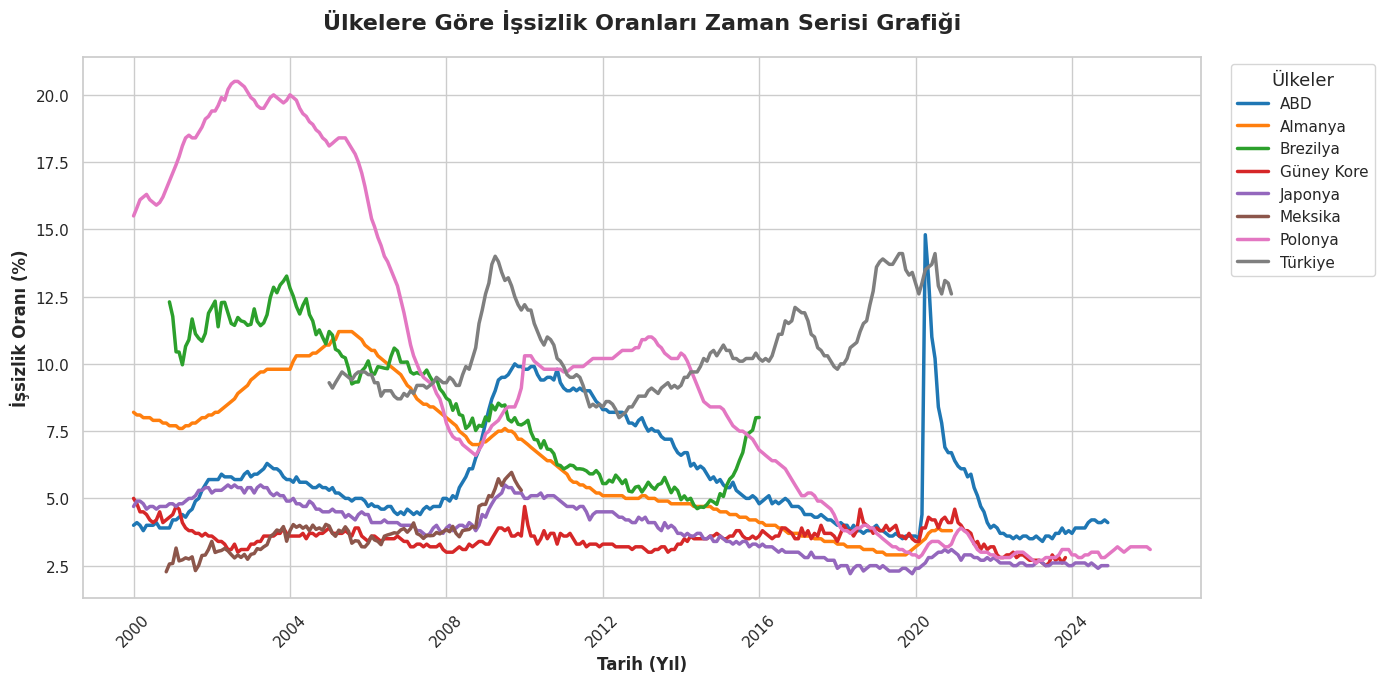

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Adım: Birleştirdiğimiz ana veriyi oku
# (Eğer dosya adını veya yolunu değiştirdiysen burayı güncellemelisin)
dosya_yolu = '/content/drive/MyDrive/TOTTİK/Veri Analizi/veri/hepsi_bir_arada_ulkeler_verisi.csv'
df = pd.read_csv(dosya_yolu)

# Tarih sütununun grafik tarafından doğru anlaşıldığından emin ol
df['Tarih'] = pd.to_datetime(df['Tarih'])

# 2. Adım: Grafiğin estetik ayarları (Tez formatına uygun)
plt.figure(figsize=(14, 7)) # Grafiğin en/boy oranı
sns.set_theme(style="whitegrid") # Arka plana okumayı kolaylaştıran ızgara ekle

# 3. Adım: Çizgi grafiğini oluştur
# hue='Ülke' parametresi, her ülke için farklı renkte bir çizgi çizer
sns.lineplot(data=df,
             x='Tarih',
             y='ISSIZLIK',
             hue='Ülke',
             linewidth=2.5, # Çizgi kalınlığı
             palette='tab10') # Renk paleti

# 4. Adım: Başlık, Eksen İsimleri ve Etiketler
plt.title('Ülkelere Göre İşsizlik Oranları Zaman Serisi Grafiği', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tarih (Yıl)', fontsize=12, fontweight='bold')
plt.ylabel('İşsizlik Oranı (%)', fontsize=12, fontweight='bold')

# Lejantı (Ülke isimleri kutusu) grafiğin dışına taşı ki çizgileri kapatmasın
plt.legend(title='Ülkeler', title_fontsize='13', fontsize='11', bbox_to_anchor=(1.02, 1), loc='upper left')

# X eksenindeki tarihleri sıkışmaması için hafif eğimli yazdır
plt.xticks(rotation=45)

# 5. Adım: Grafiği Göster ve Yüksek Çözünürlüklü Kaydet
plt.tight_layout() # Düzeni sıkıştırıp taşmaları önler

# İstersen bu kodu aktif edip grafiği doğrudan Drive'ına PNG olarak kaydedebilirsin
# plt.savefig('/content/drive/MyDrive/TOTTİK/Veri Analizi/issizlik_grafiyi.png', dpi=300)

plt.show()

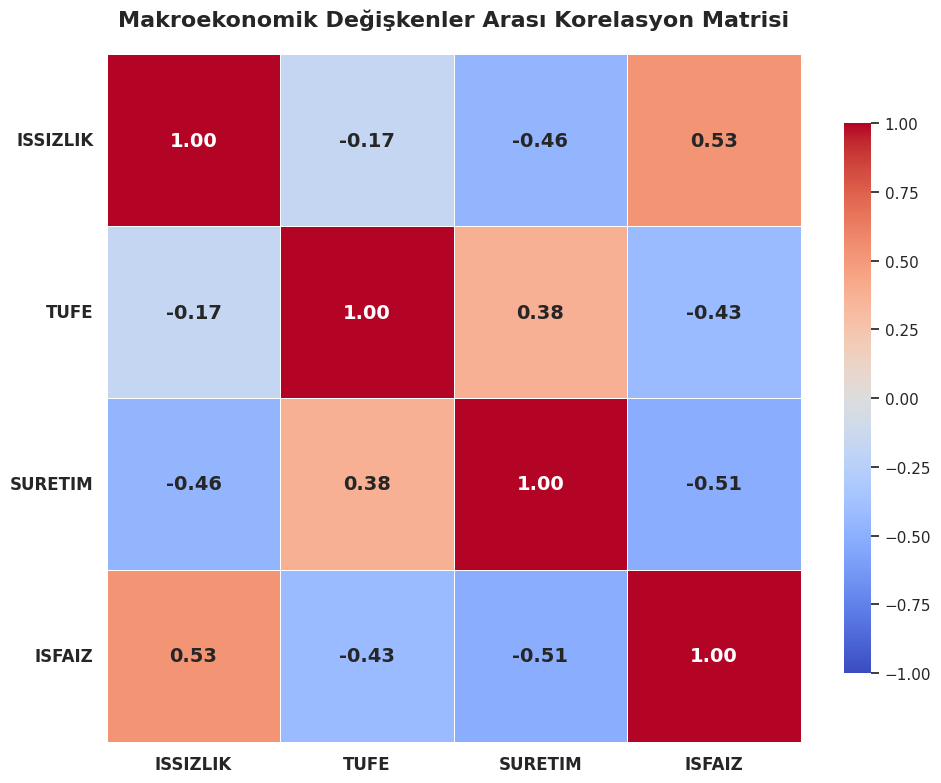

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Adım: Birleştirdiğimiz ana veriyi oku
dosya_yolu = '/content/drive/MyDrive/TOTTİK/Veri Analizi/veri/hepsi_bir_arada_ulkeler_verisi.csv'
df = pd.read_csv(dosya_yolu)

# 2. Adım: Sadece sayısal makroekonomik değişkenleri seç
# (Tarih ve Ülke sütunları matematiksel korelasyon hesabına giremez)
sayisal_sutunlar = ['ISSIZLIK', 'TUFE', 'SURETIM', 'ISFAIZ']
korelasyon_verisi = df[sayisal_sutunlar]

# 3. Adım: Korelasyon Matrisini Hesapla (Standart Pearson yöntemi)
korelasyon_matrisi = korelasyon_verisi.corr()

# 4. Adım: Grafiğin Estetik Ayarları (Tez formatı)
plt.figure(figsize=(10, 8)) # Grafiğin en ve boy oranı

# 5. Adım: Seaborn kütüphanesi ile ısı haritasını çizdir
sns.heatmap(korelasyon_matrisi,
            annot=True,              # Kutucukların içine oranları yaz
            fmt=".2f",               # Virgülden sonra sadece 2 basamak göster (ör: 0.85)
            cmap='coolwarm',         # Renk paleti (Görselindeki gibi kırmızı-mavi tonları)
            vmin=-1, vmax=1,         # Korelasyon sınırlarını -1 ile +1 arası sabitle
            linewidths=0.5,          # Kutucuklar arasına ince ayırıcı çizgiler çek
            annot_kws={"size": 14, "weight": "bold"}, # İçerideki sayıların boyutu ve kalınlığı
            cbar_kws={"shrink": 0.8}) # Yandaki renk skalasının boyutu

# 6. Adım: Başlık ve Eksen İsimlendirmeleri
plt.title('Makroekonomik Değişkenler Arası Korelasyon Matrisi', fontsize=16, fontweight='bold', pad=20)
plt.xticks(fontsize=12, fontweight='bold', rotation=0)
plt.yticks(fontsize=12, fontweight='bold', rotation=0)

# Tez için yüksek çözünürlüklü (300 dpi) kaydetme opsiyonu
# (Drive'ına PNG olarak kaydetmek istersen aşağıdaki satırın başındaki '#' işaretini kaldır)
# plt.savefig('/content/drive/MyDrive/TOTTİK/Veri Analizi/korelasyon_haritasi.png', dpi=300, bbox_inches='tight')

# Grafiği ekrana bas
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import os

# 1. Drive Bağlantısı ve Veri Okuma
drive.mount('/content/drive', force_remount=True)
dosya_yolu = '/content/drive/MyDrive/TOTTİK/Veri Analizi/veri/hepsi_bir_arada_ulkeler_verisi.csv'
df_birlestirilmis = pd.read_csv(dosya_yolu)

df_birlestirilmis['Tarih'] = pd.to_datetime(df_birlestirilmis['Tarih'])
df_birlestirilmis = df_birlestirilmis.sort_values(by=['Ülke', 'Tarih'])

# 2. Eksik Veri Tamamlama
sayisal_sutunlar = ['ISSIZLIK', 'TUFE', 'SURETIM', 'ISFAIZ']
for ulke in df_birlestirilmis['Ülke'].unique():
    mask = df_birlestirilmis['Ülke'] == ulke
    df_birlestirilmis.loc[mask, sayisal_sutunlar] = df_birlestirilmis.loc[mask, sayisal_sutunlar].interpolate(method='linear').ffill().bfill()

# 3. Veri Ön İşleme (Ülkeleri Kukla Değişkene Çevirme)
df_encoded = pd.get_dummies(df_birlestirilmis, columns=['Ülke'])

X_sutunlari = [col for col in df_encoded.columns if col not in ['Tarih', 'ISSIZLIK']]
X = df_encoded[X_sutunlari]
y = df_encoded['ISSIZLIK']

# 4. Eğitim ve Test Ayrımı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. XGBoost Parametreleri ve Model Eğitimi
xgb_parametreler = {
    'learning_rate': 0.05,
    'n_estimators': 1000,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'early_stopping_rounds': 50,
    'random_state': 42
}

model = XGBRegressor(**xgb_parametreler)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# 6. Tahmin ve Metrik Hesaplama
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# 7. TEZ İÇİN ÖZEL SONUÇ TABLOSU OLUŞTURMA
tablo_verisi = {
    'Model Parametreleri / Metrikler': [
        'Öğrenme Oranı (Learning Rate)',
        'Ağaç Sayısı (n_estimators)',
        'Maksimum Derinlik (max_depth)',
        'Alt Örneklem Oranı (subsample)',
        'Sütun Örneklem Oranı (colsample_bytree)',
        'Erken Durdurma (early_stopping_rounds)',
        'Belirlilik Katsayısı (R²)',
        'Ortalama Mutlak Hata (MAE)',
        'Kök Ortalama Kare Hata (RMSE)'
    ],
    'Değerler': [
        xgb_parametreler['learning_rate'],
        xgb_parametreler['n_estimators'],
        xgb_parametreler['max_depth'],
        xgb_parametreler['subsample'],
        xgb_parametreler['colsample_bytree'],
        xgb_parametreler['early_stopping_rounds'],
        f"% {(r2 * 100):.2f}",
        f"{mae:.3f}",
        f"{rmse:.3f}"
    ],
    'Açıklama': [
        'Modelin her bir adımdaki öğrenme hızı (Aşırı öğrenmeyi engeller)',
        'Kurulan ardışık karar ağacı sayısı',
        'Her bir karar ağacının inebileceği maksimum derinlik',
        'Her ağaç için rastgele seçilen gözlem oranı (Gürültüyü azaltır)',
        'Her ağaçta kullanılan rastgele değişken oranı',
        '50 adım boyunca hata düşmezse eğitimi durdurma kuralı',
        f'Modelin işsizlikteki değişimi açıklama gücü (R²)',
        'Tahminlerin gerçek değerden ortalama mutlak sapması',
        'Büyük sapmaların cezalandırıldığı karekök hata payı'
    ]
}

df_sonuclar = pd.DataFrame(tablo_verisi)

# Tabloyu jilet gibi ekrana bastırıyoruz
print("\n" + "="*80)
print("🎯 XGBOOST MODEL PARAMETRELERİ VE PERFORMANS METRİKLERİ TABLOSU")
print("="*80)
# Pandas tablosunu Markdown formatında çizdiriyoruz (kopyalaması çok kolay olur)
print(df_sonuclar.to_markdown(index=False))
print("="*80 + "\n")

Mounted at /content/drive

🎯 XGBOOST MODEL PARAMETRELERİ VE PERFORMANS METRİKLERİ TABLOSU
| Model Parametreleri / Metrikler         | Değerler   | Açıklama                                                         |
|:----------------------------------------|:-----------|:-----------------------------------------------------------------|
| Öğrenme Oranı (Learning Rate)           | 0.05       | Modelin her bir adımdaki öğrenme hızı (Aşırı öğrenmeyi engeller) |
| Ağaç Sayısı (n_estimators)              | 1000       | Kurulan ardışık karar ağacı sayısı                               |
| Maksimum Derinlik (max_depth)           | 6          | Her bir karar ağacının inebileceği maksimum derinlik             |
| Alt Örneklem Oranı (subsample)          | 0.8        | Her ağaç için rastgele seçilen gözlem oranı (Gürültüyü azaltır)  |
| Sütun Örneklem Oranı (colsample_bytree) | 0.8        | Her ağaçta kullanılan rastgele değişken oranı                    |
| Erken Durdurma (early_stopping_rounds)  

Mounted at /content/drive
--------------------------------------------------
🏆 8 ÜLKELİ YENİ MODEL PERFORMANSI
--------------------------------------------------
R² Skoru: %99.37
MAE (Ortalama Mutlak Hata): 0.1693
RMSE (Hata Kareleri Ortalamasının Karekökü): 0.2813
--------------------------------------------------


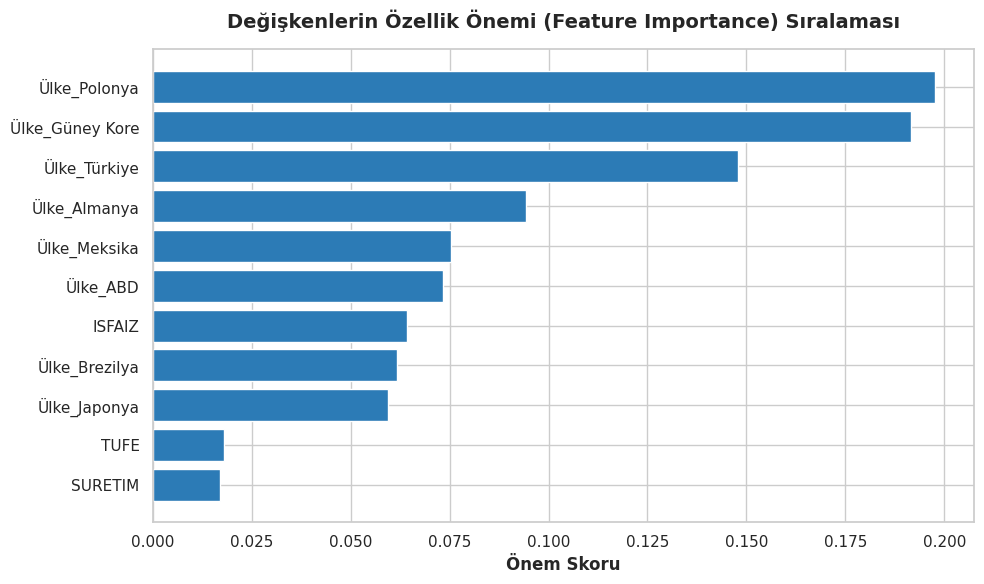

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import os

# 1. Drive Bağlantısı ve Dosya Okuma
drive.mount('/content/drive', force_remount=True)
klasor_yolu = '/content/drive/MyDrive/TOTTİK/Veri Analizi/veri/'

# Artık tek tek dosya aramıyoruz, birleştirdiğimiz ana veriyi okuyoruz
dosya_yolu = os.path.join(klasor_yolu, 'hepsi_bir_arada_ulkeler_verisi.csv')
df_birlestirilmis = pd.read_csv(dosya_yolu)

# Tarih formatını ayarla ve modeli yanıltmamak için sırala
df_birlestirilmis['Tarih'] = pd.to_datetime(df_birlestirilmis['Tarih'])
df_birlestirilmis = df_birlestirilmis.sort_values(by=['Ülke', 'Tarih'])

# 2. Eksik Veri Tamamlama (Kritik Adım)
# Meksika'nın faizi gibi NaN değerler, bulunduğu ülkenin trendine göre doldurulur
sayisal_sutunlar = ['ISSIZLIK', 'TUFE', 'SURETIM', 'ISFAIZ']
for ulke in df_birlestirilmis['Ülke'].unique():
    mask = df_birlestirilmis['Ülke'] == ulke
    df_birlestirilmis.loc[mask, sayisal_sutunlar] = df_birlestirilmis.loc[mask, sayisal_sutunlar].interpolate(method='linear').ffill().bfill()

# 3. VERİ ÖN İŞLEME (One-Hot Encoding)
# 8 ülkeyi modelin anlayacağı kukla değişkene (dummy variable) çeviriyoruz
df_encoded = pd.get_dummies(df_birlestirilmis, columns=['Ülke'])

# X (Bağımsız Değişkenler) ve y (Bağımlı Değişken)
X_sutunlari = [col for col in df_encoded.columns if col not in ['Tarih', 'ISSIZLIK']]
X = df_encoded[X_sutunlari]
y = df_encoded['ISSIZLIK']

# 4. Eğitim Yöntemi: Rassal Ayrım (Random Train-Test Split)
# Veriyi iyice karıştırarak %80 Eğitim, %20 Test olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. XGBoost Modelinin Kurulması
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# 6. Tahmin ve Performans Metrikleri
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("-" * 50)
print("🏆 8 ÜLKELİ YENİ MODEL PERFORMANSI")
print("-" * 50)
print(f"R² Skoru: %{r2 * 100:.2f}")
print(f"MAE (Ortalama Mutlak Hata): {mae:.4f}")
print(f"RMSE (Hata Kareleri Ortalamasının Karekökü): {rmse:.4f}")
print("-" * 50)

# 7. Özellik Önemi Görselleştirme (Feature Importance)
plt.figure(figsize=(10, 6))
importances = model.feature_importances_
indices = np.argsort(importances)
feature_names = X.columns

plt.title('Değişkenlerin Özellik Önemi (Feature Importance) Sıralaması', fontsize=14, fontweight='bold', pad=15)
plt.barh(range(len(indices)), importances[indices], color='#2c7bb6', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices], fontsize=11)
plt.xlabel('Önem Skoru', fontsize=12, fontweight='bold')
plt.tight_layout()

# Grafiği kaydetmek istersen alttaki satırın başındaki '#' işaretini kaldır
# plt.savefig('/content/drive/MyDrive/TOTTİK/Veri Analizi/yeni_ozellik_onemi.png', dpi=300)

plt.show()

Mounted at /content/drive
🎉 Harika! Yüksek çözünürlüklü 2x4 yatay grafik Drive'a kaydedildi:
/content/drive/MyDrive/TOTTİK/Veri Analizi/8_ulke_gercek_vs_tahmin_2x4_Yatay.png


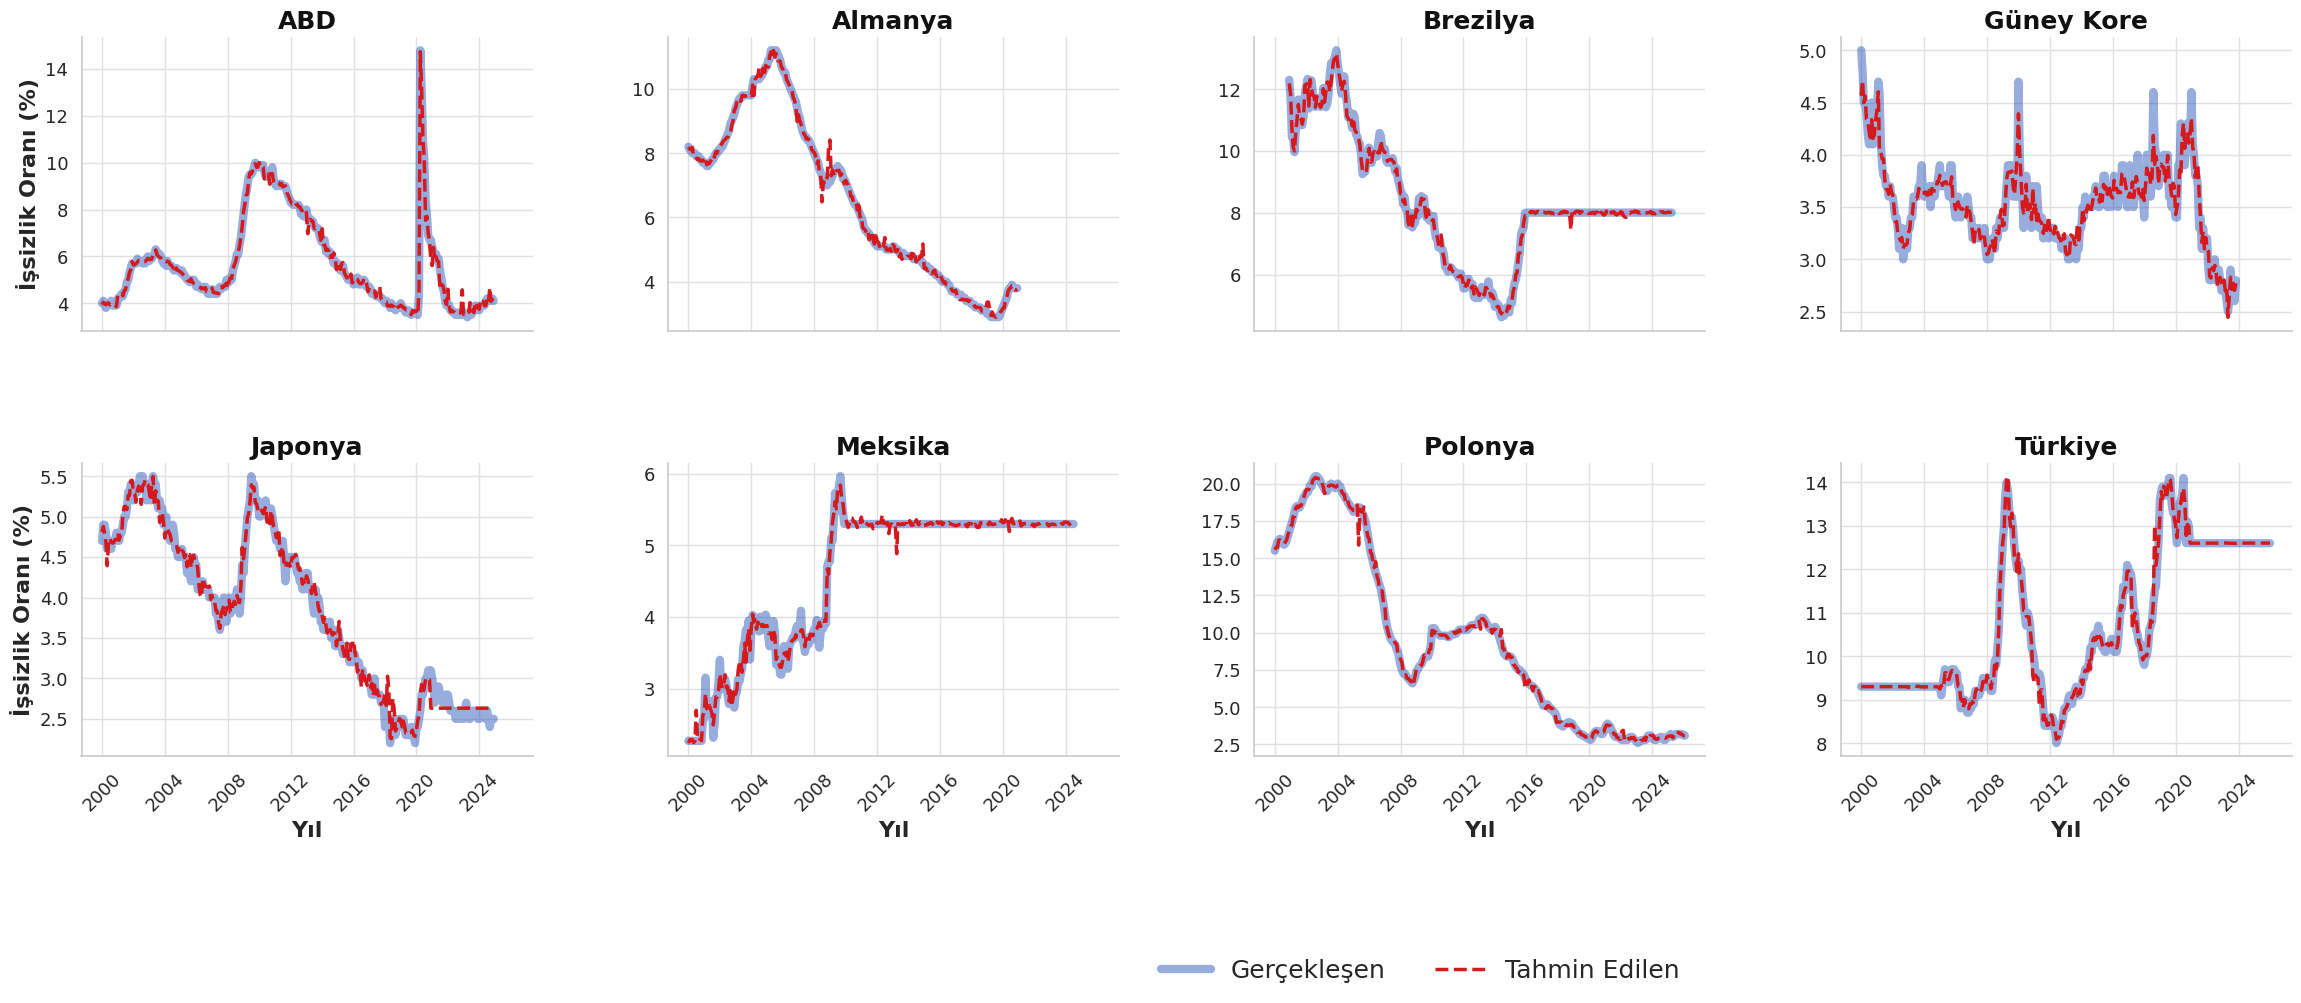

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import os

# 1. Drive Bağlantısı ve Tek Parça Ana Veriyi Okuma
drive.mount('/content/drive', force_remount=True)
dosya_yolu = '/content/drive/MyDrive/TOTTİK/Veri Analizi/veri/hepsi_bir_arada_ulkeler_verisi.csv'

df_birlestirilmis = pd.read_csv(dosya_yolu)
df_birlestirilmis['Tarih'] = pd.to_datetime(df_birlestirilmis['Tarih'])
df_birlestirilmis = df_birlestirilmis.sort_values(by=['Ülke', 'Tarih'])

# 2. Eksik Veri Tamamlama
sayisal_sutunlar = ['ISSIZLIK', 'TUFE', 'SURETIM', 'ISFAIZ']
for ulke in df_birlestirilmis['Ülke'].unique():
    mask = df_birlestirilmis['Ülke'] == ulke
    df_birlestirilmis.loc[mask, sayisal_sutunlar] = df_birlestirilmis.loc[mask, sayisal_sutunlar].interpolate(method='linear').ffill().bfill()

# 3. VERİ ÖN İŞLEME (One-Hot Encoding)
df_encoded = pd.get_dummies(df_birlestirilmis, columns=['Ülke'])

X_sutunlari = [col for col in df_encoded.columns if col not in ['Tarih', 'ISSIZLIK']]
X = df_encoded[X_sutunlari]
y = df_encoded['ISSIZLIK']

# 4. Rassal Ayrım
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. XGBoost Modelinin Kurulması
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# 6. TÜM VERİ İÇİN TAHMİN (Grafikte göstermek için)
df_birlestirilmis['Tahmin'] = model.predict(X)

# ---------------------------------------------------------
# 7. POSTER İÇİN ÖZEL GÖRSELLEŞTİRME (Kırmızı Tahmin & 2x4 Düzen)
# ---------------------------------------------------------
sns.set_theme(style="whitegrid", rc={
    "axes.facecolor": "none",
    "figure.facecolor": "none",
    "grid.color": "#e0e0e0"
})
plt.rcParams.update({'font.size': 14, 'axes.labelweight': 'bold'})

# col_wrap=4 yaparak 2 SATIR, 4 SÜTUNLUK yatay bir dizilim sağlıyoruz.
# Yan yana daralmamaları için height ve aspect değerlerini biraz optimize ettik.
g = sns.FacetGrid(df_birlestirilmis, col="Ülke", col_wrap=4, height=4.5, aspect=1.3, sharey=False)

def plot_gercek_vs_tahmin(data, **kwargs):
    # Gerçekleşen: #1a4ab4 (Lacivert/Mavi)
    sns.lineplot(data=data, x='Tarih', y='ISSIZLIK', label='Gerçekleşen',
                 color='#1a4ab4', linewidth=6.0, alpha=0.45)

    # Tahmin Edilen: #d7191c (Kırmızı)
    sns.lineplot(data=data, x='Tarih', y='Tahmin', label='Tahmin Edilen',
                 color='#d7191c', linestyle='--', linewidth=2.5, alpha=1.0)

g.map_dataframe(plot_gercek_vs_tahmin)

# Başlık ve eksen estetikleri
g.set_titles(col_template="{col_name}", size=18, fontweight='bold', color='#111111')
g.set_axis_labels("Yıl", "İşsizlik Oranı (%)", fontsize=16)
g.tick_params(labelsize=13)

# DİKKAT: 4 sütun yan yana geldiğinde tarihler (yıllar) çarpışmasın diye eğik yazdırıyoruz
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)

# LEJANT VE BOŞLUK AYARI
g.add_legend(title="", bbox_to_anchor=(0.5, -0.05), loc='upper center',
             ncol=2, frameon=False, fontsize=18)

# Ülkeler arası boşluklar ve en alt boşluk (lejanta yer açmak için bottom arttırıldı)
plt.subplots_adjust(hspace=0.45, wspace=0.30, bottom=0.15)

# Grafiği direkt Drive'a kaydet (Yeni isimle)
kayit_yolu = '/content/drive/MyDrive/TOTTİK/Veri Analizi/8_ulke_gercek_vs_tahmin_2x4_Yatay.png'
plt.savefig(kayit_yolu, dpi=400, bbox_inches='tight', transparent=True)
print(f"🎉 Harika! Yüksek çözünürlüklü 2x4 yatay grafik Drive'a kaydedildi:\n{kayit_yolu}")

plt.show()